In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv',
 'hyperparameter_tuning_dataset.csv',
 'evaluation_threshold_calibration_dataset.csv',
 'student_performance.csv',
 'student_performance_mlops.csv']

In [5]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')



END-TO-END MLOPS PROJECT
MLflow + DVC + Drift Simulation

LOADING DATA
Dataset loaded successfully!
Rows: 400
Columns: 9

First 5 rows:
   study_hours  attendance  previous_score  assignments_completed  \
0         3.62       59.64           78.90                      8   
1         7.66       95.61           48.39                      2   
2         6.12       77.74           71.70                      7   
3         5.19       92.19           73.37                      4   
4         2.09       69.40           63.33                      8   

   sleep_hours  internet_access  extracurricular  final_score  pass  
0         8.11                0                0        65.48     1  
1         6.12                1                1        75.41     1  
2         7.34                1                0        80.31     1  
3         4.48                0                0        66.01     1  
4         7.12                0                0        65.52     1  

BASELINE MODEL TRAINING


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2026/09/28 16:20:59 WARNING mlflow.models.model: 


Baseline Accuracy:
0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.95      1.00      0.97        76

    accuracy                           0.95        80
   macro avg       0.47      0.50      0.49        80
weighted avg       0.90      0.95      0.93        80


MLflow baseline run completed.

CREATING DRIFTED DATA
Drifted dataset saved: data/drifted_student_data.csv

DATA DRIFT ANALYSIS
          feature  original_mean  drifted_mean  percentage_change
0     study_hours       4.459625      2.898756         -35.000000
1      attendance      77.487475     65.487475         -15.486374
2  previous_score      67.695300     59.695300         -11.817659
3     sleep_hours       6.506075      5.506075         -15.370250


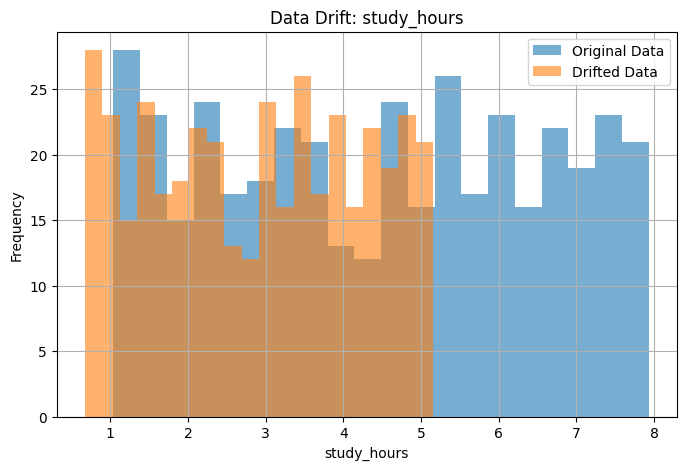

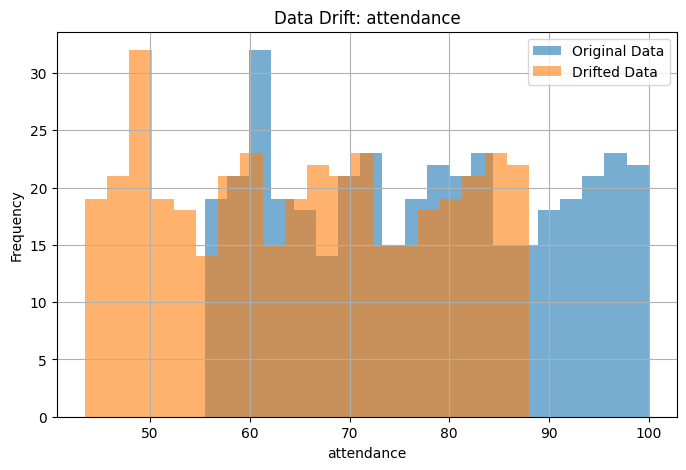

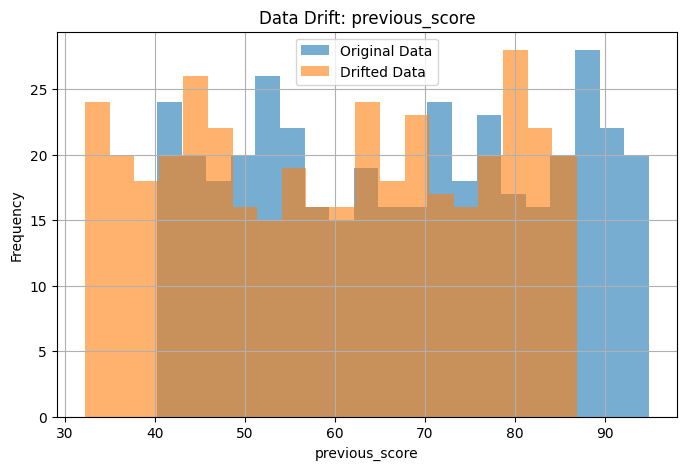

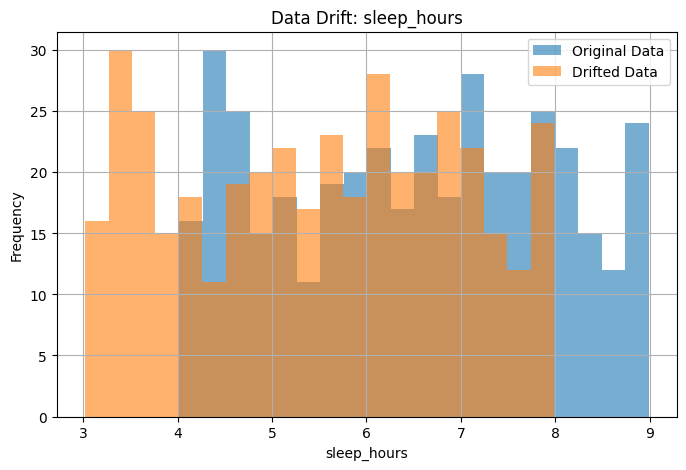


DRIFTED DATA MODEL TRAINING


2026/09/28 16:21:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Drifted Data Accuracy:
0.95

MLflow drifted-data run completed.

FINAL MLOPS RESULTS
Baseline Accuracy: 0.95
Drifted Data Accuracy: 0.95

Drift Report:
          feature  original_mean  drifted_mean  percentage_change
0     study_hours       4.459625      2.898756         -35.000000
1      attendance      77.487475     65.487475         -15.486374
2  previous_score      67.695300     59.695300         -11.817659
3     sleep_hours       6.506075      5.506075         -15.370250

Project completed successfully!


In [9]:
# ============================================================
# END-TO-END MLOPS PROJECT
# MLflow + DVC + Data Drift Simulation
#
# Project:
# Student Performance Prediction
# ============================================================

!pip install mlflow
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_PATH = "/content/drive/MyDrive/Colab/student_performance_mlops.csv"

FEATURES = [
    "study_hours",
    "attendance",
    "previous_score",
    "assignments_completed",
    "sleep_hours",
    "internet_access",
    "extracurricular"
]

TARGET = "pass"


# ============================================================
# 2. LOAD DATA
# ============================================================

def load_data():

    print("\n" + "=" * 60)
    print("LOADING DATA")
    print("=" * 60)

    df = pd.read_csv(DATA_PATH)

    print("Dataset loaded successfully!")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    print("\nFirst 5 rows:")
    print(df.head())

    return df


# ============================================================
# 3. PREPARE DATA
# ============================================================

def prepare_data(df):

    X = df[FEATURES]

    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test


# ============================================================
# 4. CREATE ML PIPELINE
# ============================================================

def create_model():

    model = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=42
            )
        )
    ])

    return model


# ============================================================
# 5. TRAIN BASELINE MODEL
# ============================================================

def train_baseline(df):

    print("\n" + "=" * 60)
    print("BASELINE MODEL TRAINING")
    print("=" * 60)

    X_train, X_test, y_train, y_test = prepare_data(df)

    model = create_model()

    # Start MLflow experiment
    mlflow.set_experiment(
        "Student_Performance_MLOps"
    )

    with mlflow.start_run(
        run_name="baseline_model"
    ):

        # Train
        model.fit(
            X_train,
            y_train
        )

        # Predict
        predictions = model.predict(
            X_test
        )

        # Accuracy
        accuracy = accuracy_score(
            y_test,
            predictions
        )

        print("\nBaseline Accuracy:")
        print(accuracy)

        print("\nClassification Report:")
        print(
            classification_report(
                y_test,
                predictions
            )
        )

        # Log parameters
        mlflow.log_param(
            "model",
            "RandomForestClassifier"
        )

        mlflow.log_param(
            "n_estimators",
            100
        )

        mlflow.log_param(
            "max_depth",
            10
        )

        # Log metric
        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        # Save model in MLflow
        mlflow.sklearn.log_model(
            model,
            "student_model",
            skops_trusted_types=['sklearn.tree._tree.Tree']
        )

        print("\nMLflow baseline run completed.")

    return model, accuracy


# ============================================================
# 6. CREATE DRIFTED DATA
# ============================================================

def create_drifted_data(df):

    print("\n" + "=" * 60)
    print("CREATING DRIFTED DATA")
    print("=" * 60)

    drifted = df.copy()

    # Simulate real-world changes

    # Students study fewer hours
    drifted["study_hours"] = (
        drifted["study_hours"] * 0.65
    )

    # Lower attendance
    drifted["attendance"] = (
        drifted["attendance"] - 12
    )

    # Lower previous score
    drifted["previous_score"] = (
        drifted["previous_score"] - 8
    )

    # Less sleep
    drifted["sleep_hours"] = (
        drifted["sleep_hours"] - 1
    )

    # Keep values in realistic ranges
    drifted["study_hours"] = drifted[
        "study_hours"
    ].clip(0, 8)

    drifted["attendance"] = drifted[
        "attendance"
    ].clip(0, 100)

    drifted["previous_score"] = drifted[
        "previous_score"
    ].clip(0, 100)

    drifted["sleep_hours"] = drifted[
        "sleep_hours"
    ].clip(0, 12)

    # Save drifted dataset
    drifted.to_csv(
        "data/drifted_student_data.csv",
        index=False
    )

    print(
        "Drifted dataset saved:"
        " data/drifted_student_data.csv"
    )

    return drifted


# ============================================================
# 7. CALCULATE DATA DRIFT
# ============================================================

def calculate_drift(original, drifted):

    print("\n" + "=" * 60)
    print("DATA DRIFT ANALYSIS")
    print("=" * 60)

    results = []

    numeric_features = [
        "study_hours",
        "attendance",
        "previous_score",
        "sleep_hours"
    ]

    for feature in numeric_features:

        original_mean = original[
            feature
        ].mean()

        drifted_mean = drifted[
            feature
        ].mean()

        percentage_change = (
            (drifted_mean - original_mean)
            / original_mean
        ) * 100

        results.append({

            "feature": feature,

            "original_mean":
                original_mean,

            "drifted_mean":
                drifted_mean,

            "percentage_change":
                percentage_change
        })

    drift_report = pd.DataFrame(
        results
    )

    print(drift_report)

    drift_report.to_csv(
        "data/drift_report.csv",
        index=False
    )

    return drift_report


# ============================================================
# 8. VISUALIZE DRIFT
# ============================================================

def plot_drift(original, drifted):

    features = [
        "study_hours",
        "attendance",
        "previous_score",
        "sleep_hours"
    ]

    for feature in features:

        plt.figure(figsize=(8, 5))

        plt.hist(
            original[feature],
            bins=20,
            alpha=0.6,
            label="Original Data"
        )

        plt.hist(
            drifted[feature],
            bins=20,
            alpha=0.6,
            label="Drifted Data"
        )

        plt.xlabel(feature)

        plt.ylabel("Frequency")

        plt.title(
            "Data Drift: " + feature
        )

        plt.legend()

        plt.grid()

        filename = (
            "data/drift_"
            + feature
            + ".png"
        )

        plt.savefig(
            filename
        )

        plt.show()


# ============================================================
# 9. TRAIN MODEL ON DRIFTED DATA
# ============================================================

def train_drifted_model(drifted):

    print("\n" + "=" * 60)
    print("DRIFTED DATA MODEL TRAINING")
    print("=" * 60)

    X_train, X_test, y_train, y_test = (
        prepare_data(drifted)
    )

    model = create_model()

    with mlflow.start_run(
        run_name="drifted_data_model"
    ):

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        accuracy = accuracy_score(
            y_test,
            predictions
        )

        print(
            "\nDrifted Data Accuracy:"
        )

        print(accuracy)

        # Log information to MLflow
        mlflow.log_param(
            "model",
            "RandomForestClassifier"
        )

        mlflow.log_param(
            "dataset",
            "drifted_data"
        )

        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        mlflow.sklearn.log_model(
            model,
            "drifted_student_model",
            skops_trusted_types=['sklearn.tree._tree.Tree']
        )

        print(
            "\nMLflow drifted-data run completed."
        )

    return model, accuracy


# ============================================================
# 10. MAIN PROGRAM
# ============================================================

if __name__ == "__main__":

    print("\n")
    print("=" * 60)
    print("END-TO-END MLOPS PROJECT")
    print("MLflow + DVC + Drift Simulation")
    print("=" * 60)

    # Create data folder if required
    os.makedirs(
        "data",
        exist_ok=True
    )

    # --------------------------------------------------------
    # Step 1: Load original data
    # --------------------------------------------------------

    original_data = load_data()

    # --------------------------------------------------------
    # Step 2: Train baseline model
    # --------------------------------------------------------

    baseline_model, baseline_accuracy = (
        train_baseline(
            original_data
        )
    )

    # --------------------------------------------------------
    # Step 3: Create drift
    # --------------------------------------------------------

    drifted_data = create_drifted_data(
        original_data
    )

    # --------------------------------------------------------
    # Step 4: Calculate drift
    # --------------------------------------------------------

    drift_report = calculate_drift(
        original_data,
        drifted_data
    )

    # --------------------------------------------------------
    # Step 5: Plot drift
    # --------------------------------------------------------

    plot_drift(
        original_data,
        drifted_data
    )

    # --------------------------------------------------------
    # Step 6: Train model on drifted data
    # --------------------------------------------------------

    drifted_model, drifted_accuracy = (
        train_drifted_model(
            drifted_data
        )
    )

    # --------------------------------------------------------
    # Step 7: Final comparison
    # --------------------------------------------------------

    print("\n" + "=" * 60)
    print("FINAL MLOPS RESULTS")
    print("=" * 60)

    print(
        "Baseline Accuracy:",
        baseline_accuracy
    )

    print(
        "Drifted Data Accuracy:",
        drifted_accuracy
    )

    print(
        "\nDrift Report:"
    )

    print(
        drift_report
    )

    print("\nProject completed successfully!")